# Titanic Survival — Exploratory Data Analysis (EDA)

Goal of this notebook: Explore and understand the data well enough to find hidden patterns and use them for preprocessing and other training decisions made in `train.py`.

## 1. What the data contains?

891 passengers, 12 columns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 100

DATA_PATH = Path("data") / "train.csv"
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"{DATA_PATH} not found. Run `python fetch_data.py` from the project root first."
    )

df = pd.read_csv(DATA_PATH)
df.shape

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Summary of properties: 

Property | type | number missing | percentile missing | number of unique values

In [2]:
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(1),
    "n_unique": df.nunique(),
})
summary

,dtype,n_missing,pct_missing,n_unique
PassengerId,int64,0,0.0,891
Survived,int64,0,0.0,2
Pclass,int64,0,0.0,3
Name,str,0,0.0,891
Sex,str,0,0.0,2
Age,float64,177,19.9,88
SibSp,int64,0,0.0,7
Parch,int64,0,0.0,7
Ticket,str,0,0.0,681
Fare,float64,0,0.0,248


**Column reference** (for the ones that aren't self-explanatory):

| Column | Meaning |
|---|---|
| `Survived` | Target. 0 = died, 1 = survived |
| `Pclass` | Ticket class, 1/2/3 — proxy for socio-economic status |
| `SibSp` | # siblings/spouses aboard |
| `Parch` | # parents/children aboard |
| `Fare` | Passenger fare |
| `Embarked` | Port of embarkation: C = Cherbourg, Q = Queenstown, S = Southampton |

* `PassengerId` is a row index with no predictive value. 

* `Name`, `Ticket`, `Cabin` are free text — not useful in raw form

* `Cabin` (see §3) and `Name` (see §5) have signal worth extracting. 

* `Age` (~20% missing) and `Cabin` (~77% missing) are the two columns with real missingness to handle 

* `Embarked` has 2 missing values.

## 2. Target distribution

How balanced is `Survived`?

Survived: 342 / 891  (38.4%)


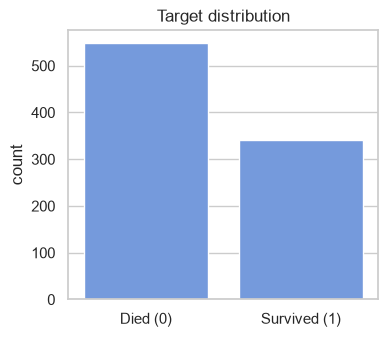

In [3]:
survival_rate = df["Survived"].mean()
print(f"Survived: {df['Survived'].sum()} / {len(df)}  ({survival_rate:.1%})")

fig, ax = plt.subplots(figsize=(4, 3.5))
sns.countplot(data=df, x="Survived", ax=ax, color="cornflowerblue")
ax.set_xticks([0, 1], ["Died (0)", "Survived (1)"])
ax.set_title("Target distribution")
ax.set_xlabel("")
plt.show()

**Finding:** ~38% survived — moderately imbalanced --> accuracy alone would be a misleading headline metric.

**Implication:** 

* Evaluate with recall/F1/confusion matrix (and ROC-AUC) rather than accuracy alone.

* Use a **stratified** train/validation split so both splits preserve the ~38% survival rate.

## 3. Missingness

Already saw in §1 (`Age` ~20%, `Cabin` ~77%, `Embarked` 2 rows). 

Is missingness itself informative?

### Cabin

What is the connection between the ticket class and missing cabin information?

In [4]:
df["HasCabin"] = df["Cabin"].notna()

cabin_vs_pclass = pd.crosstab(df["Pclass"], df["HasCabin"], normalize="index").round(2)
cabin_vs_pclass.columns = ["Cabin missing", "Cabin recorded"]
print("Share of passengers with a recorded Cabin, by Pclass:")
display(cabin_vs_pclass)

print("\nSurvival rate by whether Cabin is recorded:")
display(df.groupby("HasCabin")["Survived"].mean().round(3))

Share of passengers with a recorded Cabin, by Pclass:


,Cabin missing,Cabin recorded
Pclass,,
1,0.19,0.81
2,0.91,0.09
3,0.98,0.02



Survival rate by whether Cabin is recorded:


HasCabin
False    0.300
True     0.667
Name: Survived, dtype: float64

**Finding:** `Cabin` isn't missing at random — 1st class passengers have a recorded cabin 81% of the time, vs. 9% for 2nd class and just 2% for 3rd --> cabins were mostly logged for upper-class tickets. Survival rate is much higher when `Cabin` is recorded (67%) than when it isn't (30%) --> usable signal. 

**Implication:** Use `HasCabin` as a binary feature and don't use the raw `Cabin` column.

### Age

How does age correlate with survival?

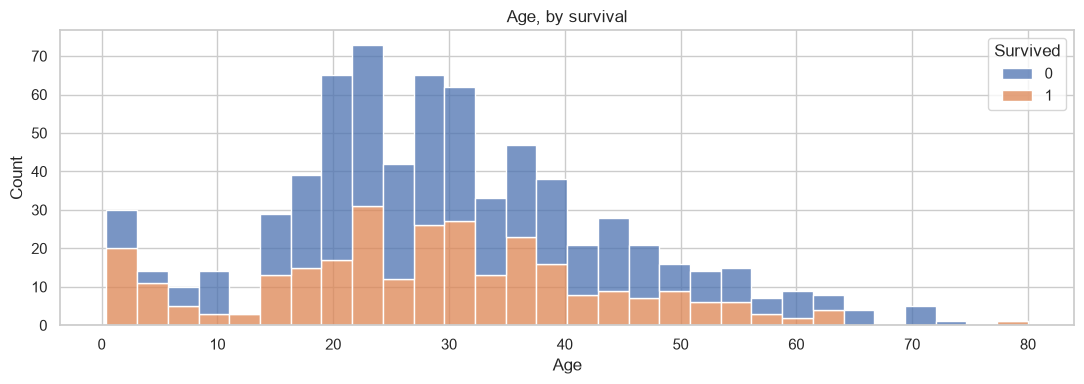

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(11, 4)) 

sns.histplot(data=df, x="Age", hue="Survived", multiple="stack", bins=30, ax=ax)
ax.set_title("Age, by survival")

plt.tight_layout()
plt.show()

In [6]:
# Children specifically — is there an age band worth flagging as its own feature?
under_16 = df["Age"] < 16
print("Survival rate, Age < 16:", round(df.loc[under_16, "Survived"].mean(), 3), f"(n={under_16.sum()})")
print("Survival rate, Age >= 16:", round(df.loc[~under_16 & df["Age"].notna(), "Survived"].mean(), 3))

Survival rate, Age < 16: 0.59 (n=83)
Survival rate, Age >= 16: 0.382


**Finding:** children skew noticeably toward survival ("women and children first").

**Implication:**

- `Age` is worth keeping. If missing —-> choose median age grouped by `Pclass`+`Title (Mr/Mrs/Miss/Master)` which is indicative of age.

- An `IsChild` (Age < 16) binary flag is added.

### Embarked

Since only two values are missing, they'll be filled with the mode — Southampton, the most common port.

## 4. Features & Survival rate connection 

We look for the connection between different features and survival rate.

### Fare

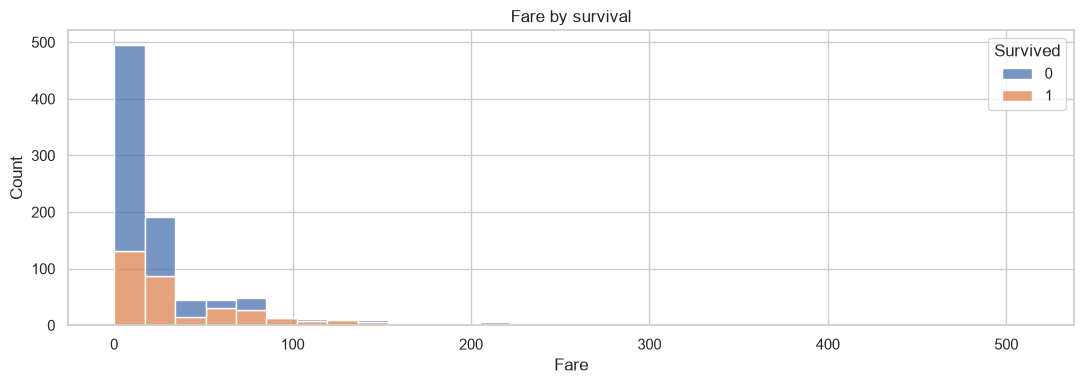

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a single plot axis named 'ax'
fig, ax = plt.subplots(1, 1, figsize=(11, 4)) 

# Pass 'ax=ax' to draw the plot on that specific axis
sns.histplot(data=df, x="Fare", hue="Survived", multiple="stack", bins=30, ax=ax)
ax.set_title("Fare by survival")

plt.tight_layout()
plt.show()

*  Higher `Fare` skews toward survival.

* `Fare` is right-skewed with a handful of extreme outliers — a log transform should be applied in preprocessing rather than feeding raw Fare to the model.


### Categorical Features

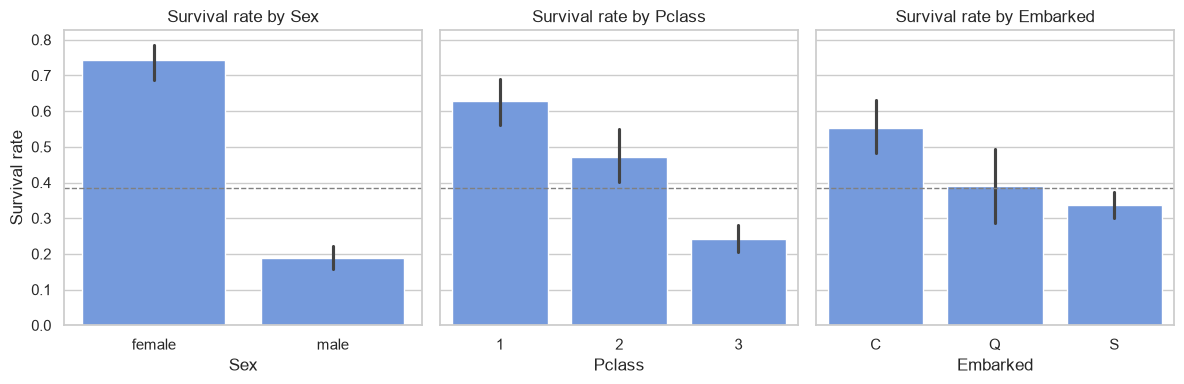

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, col in zip(axes, ["Sex", "Pclass", "Embarked"]):
    sns.barplot(data=df, x=col, y="Survived", ax=ax, color="cornflowerblue",order=sorted(df[col].dropna().unique(), key=str))
    ax.set_title(f"Survival rate by {col}")
    ax.set_ylabel("Survival rate" if col == "Sex" else "")
    ax.axhline(survival_rate, color="gray", linestyle="--", linewidth=1)  # overall rate for reference

plt.tight_layout()
plt.show()

**Finding:** 

* `Sex` is the single strongest predictor by a wide margin (women survived at far higher rates than men).

* `Pclass` shows a clean monotonic relationship — 1st class survived most, 3rd class least. 

* `Embarked` shows a smaller but real gap between ports (likely confounded with `Pclass` — passengers from different ports skewed toward different classes). 

**Implication:** all three are strong, low-cost categorical features — one-hot or ordinal-encode them (`Pclass` is already ordinal and can be kept numeric or one-hot encoded; `Sex`/`Embarked` need encoding).

## 5. Derived features — and what happens to the raw columns they come from

`Name`, `Ticket`, and `Cabin` are high-cardinality identifiers not usable in raw form, but two of them have signal worth extracting rather than just discarding.

**`Title`, from `Name`.** Every name follows `Last, Title. First...` — the title (Mr/Mrs/Miss/Master/rare) is a compact proxy for age, sex, and social status combined.

In [9]:
df["Title"] = df["Name"].str.extract(r",\s*([^.]+)\.")[0].str.strip()
df["Title"] = df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})  # French/alt spellings first

# Collapse the long tail of rare titles into a single bucket so the feature stays learnable
title_counts = df["Title"].value_counts()
rare_titles = title_counts[title_counts < 10].index
df["Title"] = df["Title"].replace(rare_titles, "Rare")

title_summary = df.groupby("Title")["Survived"].agg(["mean", "count"]).round(3).sort_values("mean", ascending=False)
title_summary.columns = ["survival_rate", "n"]
title_summary

,survival_rate,n
Title,,
Mrs,0.794,126
Miss,0.703,185
Master,0.575,40
Rare,0.348,23
Mr,0.157,517


`Title` separates survival rate more sharply than raw `Sex` alone (e.g. `Master` — young boys — survives at a noticeably higher rate than adult `Mr`, despite both being male), and it also gives a much better grouping variable for `Age` imputation than `Pclass` alone.

**`FamilySize`, from `SibSp` + `Parch`.** 

* Checking if solo travelers and very large families both did worse than small-to-mid-size families (solo = no one helping you find a lifeboat; large family = harder to keep everyone together in time).

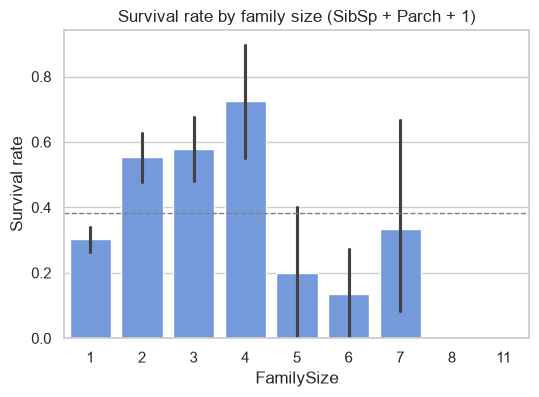

In [10]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1  # +1 for the passenger themselves

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=df, x="FamilySize", y="Survived", ax=ax, color="cornflowerblue")
ax.axhline(survival_rate, color="gray", linestyle="--", linewidth=1)
ax.set_ylabel("Survival rate")
ax.set_title("Survival rate by family size (SibSp + Parch + 1)")
plt.show()

* Confirms the expected pattern: `FamilySize == 1` (traveling alone) survives at a below-average rate, mid-size families (2-4) do best, and very large families (5+) drop off sharply, likely both effects compounded by `Pclass` (large families cluster in 3rd class). 

* In experiments we saw it is worth keeping `FamilySize` as an engineered feature — but not `SibSp`/`Parch` alongside it, since `FamilySize = SibSp + Parch + 1` by construction, so the raw pair is redundant once the total is computed.

## 6. Summary — what this means for preprocessing

- **Target is moderately imbalanced (~38% survived).** Use a **stratified** train/validation split; evaluate with precision/recall/F1/confusion matrix/ROC-AUC, not accuracy alone.

- **Drop:** `PassengerId`, `Name`, `Ticket`, `Cabin`, `SibSp`, `Parch` (raw) — no signal beyond what's extracted below, or none at all. `SibSp`/`Parch` are collinear with `FamilySize` by construction (`FamilySize = SibSp + Parch + 1`), so keeping all three would just hand the model redundant inputs.

- **Engineer:** `Title` (from `Name`, rare titles bucketed), `FamilySize` (`SibSp + Parch + 1`), `HasCabin` (from `Cabin` non-null), `IsChild` (`Age < 16`).

- **Impute:** `Age` (~20% missing) — by `Pclass`/`Title` group median, not a single global median. `Embarked` (2 missing) — filled with the mode (Southampton, the most common port). `Cabin` — not imputed, replaced entirely by `HasCabin`.

- **Encode:** `Sex`, `Embarked`, `Title` — one-hot (ordinal for `Pclass`, which already carries a meaningful order).

- **Scale/transform:** `Fare` is right-skewed with extreme outliers — log-transform before scaling. `Age` and `FamilySize` are reasonable to standardize as-is.

- All of this must be **fit on the training split only** and applied to validation (and later, inference) without re-fitting.